https://sber.ru/sberindex/konkurs_sberindex#claster

Данные:
1. https://rosstat.gov.ru/opendata/7708234640-oktmo
2. https://www.sberindex.ru/ru/dashboards/potrebitelskie-beznalicnye-rashody-na-urovne-munizipalnyh-obrazovanij
3. https://huggingface.co/datasets/CEBPM/Municipalities-of-Russia

In [5]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import geopandas as gpd

# 1. Данные

### 1.1 ОКТМО (список МО)

In [12]:
oktmo_cols = pd.read_csv('data/structure-20260210T1102.csv', sep=';')
oktmo_cols

,field name,english description,russian description,format
0,TER,region code,Код региона,varchar(2)
1,KOD1,area code/city MO,Код муниципального округа/муниципального район...,varchar(3)
2,KOD2,the code settlement,Код городского/сельского поселения,varchar(3)
3,KOD3,code locality,Код населенного пункта,varchar(3)
4,KC,check number,контрольное число,numeric(1)
5,RAZDEL,code section,Код раздела,varchar(1)
6,NAME1,the name of the site,Наименование территории,varchar(500)
7,Centrum,additional information,Дополнительная информация,varchar(250)
8,NomDescr,Description,Описание,varchar(8000)
9,NomAkt,Change number,Номер изменения,numeric(3)


In [18]:
oktmo = pd.read_csv('data/data-20260901T1609-structure-20260210T1102.csv', sep=';', header=None, names=oktmo_cols['field name'].tolist())
oktmo

,TER,KOD1,KOD2,KOD3,KC,RAZDEL,NAME1,Centrum,NomDescr,NomAkt,Status,DateUtv,DateVved
0,0,0,0,0,0,1,Раздел 1. Муниципальные образования субъектов ...,NaN,NaN,0,0,14.06.2013,01.01.2014
1,0,0,0,0,0,2,"Раздел 2. Населенные пункты, входящие в состав...",NaN,NaN,0,0,14.06.2013,01.01.2014
2,1,0,0,0,2,1,Муниципальные образования Алтайского края,NaN,NaN,0,0,14.06.2013,01.01.2014
3,1,0,0,0,2,2,"Населенные пункты, входящие в состав муниципал...",NaN,NaN,0,0,14.06.2013,01.01.2014
4,1,500,0,0,6,1,Муниципальные округа Алтайского края,NaN,NaN,493,3,12.08.2021,01.01.2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...
186528,99,630,440,116,2,2,ст Лумку-Корань,NaN,NaN,0,0,14.06.2013,01.01.2014
186529,99,700,0,0,4,1,Городские округа Еврейской автономной области/,NaN,NaN,0,0,14.06.2013,01.01.2014
186530,99,701,0,0,9,1,город Биробиджан,г Биробиджан,NaN,0,0,14.06.2013,01.01.2014
186531,99,701,0,0,9,2,"Населенные пункты, входящие в состав городског...",NaN,NaN,0,0,14.06.2013,01.01.2014


In [102]:
oktmo.query('KOD3 != 0')  # населенные пункты, без обобщающих сущностей

,TER,KOD1,KOD2,KOD3,KC,RAZDEL,NAME1,Centrum,NomDescr,NomAkt,Status,DateUtv,DateVved
7,1,512,0,101,8,2,с Залесово,NaN,NaN,493,3,12.08.2021,01.01.2022
8,1,512,0,106,2,2,с Большой Калтай,NaN,NaN,493,3,12.08.2021,01.01.2022
9,1,512,0,111,7,2,с Борисово,NaN,NaN,493,3,12.08.2021,01.01.2022
10,1,512,0,116,1,2,с Видоново,NaN,NaN,493,3,12.08.2021,01.01.2022
11,1,512,0,121,6,2,с Восход,NaN,NaN,493,3,12.08.2021,01.01.2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...
186525,99,630,440,101,9,2,с Партизанское,NaN,NaN,0,0,14.06.2013,01.01.2014
186526,99,630,440,106,3,2,с Волочаевка-1,NaN,NaN,0,0,14.06.2013,01.01.2014
186527,99,630,440,111,8,2,ст Ольгохта,NaN,NaN,0,0,14.06.2013,01.01.2014
186528,99,630,440,116,2,2,ст Лумку-Корань,NaN,NaN,0,0,14.06.2013,01.01.2014


### 1.2 Потребительские безналичные расходы на уровне МО

In [3]:
costs = pd.read_parquet('data/potrebitelskie-beznalicnye-rashody-na-urovne-munizipalnyh-obrazovanij_ru_1764079373653.parquet')
costs

,period,value,obs_status,source,category_15,mo,freq,decimals,unit_measure,unit_mult
0,2023-01-01,13815.0,A,Данные СберИндекса,Все категории,Бай-Тайгинский муниципальный район,Месяц,3,руб.,0
1,2023-02-01,15664.0,A,Данные СберИндекса,Все категории,Бай-Тайгинский муниципальный район,Месяц,3,руб.,0
2,2023-03-01,16037.0,A,Данные СберИндекса,Все категории,Бай-Тайгинский муниципальный район,Месяц,3,руб.,0
3,2023-04-01,15705.0,A,Данные СберИндекса,Все категории,Бай-Тайгинский муниципальный район,Месяц,3,руб.,0
4,2023-05-01,16080.0,A,Данные СберИндекса,Все категории,Бай-Тайгинский муниципальный район,Месяц,3,руб.,0
...,...,...,...,...,...,...,...,...,...,...
303121,2023-08-01,1334.0,A,Данные СберИндекса,Транспорт,Пинежский муниципальный округ,Месяц,3,руб.,0
303122,2023-09-01,1225.0,A,Данные СберИндекса,Транспорт,Пинежский муниципальный округ,Месяц,3,руб.,0
303123,2023-10-01,1051.0,A,Данные СберИндекса,Транспорт,Пинежский муниципальный округ,Месяц,3,руб.,0
303124,2023-11-01,813.0,A,Данные СберИндекса,Транспорт,Пинежский муниципальный округ,Месяц,3,руб.,0


In [4]:
costs.category_15.unique(), costs.freq.unique()

(<ArrowStringArray>
 [       'Все категории',             'Здоровье', 'Общественное питание',
        'Продовольствие',         'Маркетплейсы',            'Транспорт']
 Length: 6, dtype: str,
 <ArrowStringArray>
 ['Месяц']
 Length: 1, dtype: str)

In [99]:
len(costs.mo.unique()) # уникальных МО

2118

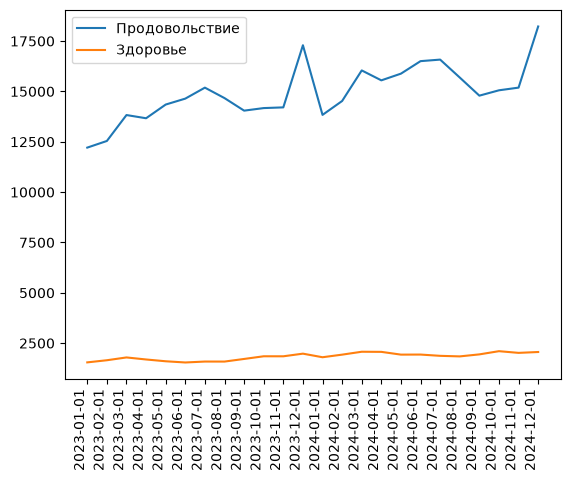

In [70]:
plt.plot(
    costs.query('mo == "городской округ город Мегион" and category_15 == "Продовольствие"')['period'],
    costs.query('mo == "городской округ город Мегион" and category_15 == "Продовольствие"')['value'],
    label='Продовольствие'
)
plt.plot(
    costs.query('mo == "городской округ город Мегион" and category_15 == "Здоровье"')['period'],
    costs.query('mo == "городской округ город Мегион" and category_15 == "Здоровье"')['value'],
    label='Здоровье'
)
plt.xticks(rotation=90, ha='right')
plt.legend()
plt.show()

In [138]:
## сбор датасета для кластеризации
categories = ['Здоровье', 'Общественное питание', 'Продовольствие', 'Маркетплейсы', 'Транспорт']
costs_filtered = costs[costs['category_15'].isin(categories)].copy()

pivot_costs = costs_filtered.pivot_table(
    index=['mo', 'period'],
    columns='category_15',
    values='value',
    aggfunc='mean'
)

pivot_costs = pivot_costs.reindex(columns=categories)

pivot_costs = pivot_costs.sort_index(level=['mo', 'period'])

mo_values = pivot_costs.index.get_level_values('mo').unique()
n_tseries = len(mo_values)
n_dimensions = len(categories)

period_counts = pivot_costs.groupby(level='mo').size()
print(f"МО с {period_counts.max()} периодами: {sum(period_counts == period_counts.max())}, МО с меньшим кол-вом периодов: {sum(period_counts < period_counts.max())}")

valid_mo = period_counts[period_counts == period_counts.max()].index
pivot_costs = pivot_costs.loc[pivot_costs.index.get_level_values('mo').isin(valid_mo)]
period_counts = pivot_costs.groupby(level='mo').size()
n_tseries = len(valid_mo)

assert period_counts.nunique() == 1
n_periods = period_counts.iloc[0]

X_train = pivot_costs.values.reshape(n_tseries, n_periods, n_dimensions)

МО с 24 периодами: 1952, МО с меньшим кол-вом периодов: 166


### 1.3 Geojson ОКТМО

In [73]:
oktmo_geo = gpd.read_file('data/Municipalities_Russia_2025.geojson')
oktmo_geo = oktmo_geo.set_crs('EPSG:3857')
oktmo_geo

,region,type,name,admcen,fo,arctic,okato,oktmo,geometry
0,Алтайский край,муниципальный район,Алейский муниципальный район,г Алейск,Сибирский,0,01201000000,01601000000,"MULTIPOLYGON (((9261395.767 6873159.859, 92674..."
1,Алтайский край,муниципальный район,Алтайский муниципальный район,с Алтайское,Сибирский,0,01202000000,01602000000,"MULTIPOLYGON (((9551392.113 6809974.372, 95511..."
2,Алтайский край,муниципальный район,Баевский муниципальный район,с Баево,Сибирский,0,01203000000,01603000000,"MULTIPOLYGON (((9025684.894 7055484.739, 90236..."
3,Алтайский край,муниципальный район,Бийский муниципальный район,г Бийск,Сибирский,0,01204000000,01604000000,"MULTIPOLYGON (((9582010.127 6948721.29, 958356..."
4,Алтайский край,муниципальный район,Благовещенский муниципальный район,рп Благовещенка,Сибирский,0,01205000000,01605000000,"MULTIPOLYGON (((8971203.02 6997278.35, 8968938..."
...,...,...,...,...,...,...,...,...,...
2669,Пермский край,муниципальный округ,муниципальный округ город Березники,г Березники,Приволжский,0,57408000000,57504000000,"MULTIPOLYGON (((6309868.773 8303538.727, 63089..."
2670,Владимирская область,городской округ,округ Муром,г Муром,Центральный,0,17435000000,17735000000,"MULTIPOLYGON (((4694827.901 7548743.428, 46954..."
2671,Нижегородская область,городской округ,город Арзамас,г Арзамас,Приволжский,0,22403000000,22703000000,"MULTIPOLYGON (((4825184.466 7450492.758, 48247..."
2672,Тверская область,муниципальный округ,Кимрский,г Кимры,Центральный,0,28228000000,28528000000,"MULTIPOLYGON (((4162465.669 7801170.346, 41621..."


In [82]:
# мэтч с тратами
costs['short_name'] = costs['mo'].apply(lambda x: ' '.join([token for token in x.split() if token[0].isupper()]))
oktmo_geo['short_name'] = oktmo_geo['name'].apply(
    lambda x: ' '.join([token for token in x.split() if token[0].isupper() and token != 'Муниципальный'])
)

costs_geo = costs.merge(oktmo_geo[['short_name', 'oktmo', 'geometry']], on='short_name', how="inner")

print(f"не нашлось географии для {len(costs.mo.unique()) - len(costs_geo.mo.unique())} ОКТМО:")
print(set(costs.mo.unique()) - set(costs_geo.mo.unique()))

не нашлось географии для 37 ОКТМО:
{'городской округ Ирбитское', 'внутригородская территория города федерального значения поселение Московский', 'внутригородская территория города федерального значения поселение Кленовское', 'внутригородская территория города федерального значения поселение Рязановское', 'городской округ город Касимов', 'городской округ город Алатырь', 'внутригородская территория города федерального значения поселение Внуковское', 'внутригородская территория города федерального значения поселение Вороновское', 'городской округ Северодвинск', 'муниципальный район Город Краснокаменск и Краснокаменский район', 'городской округ Полысаевский', 'городской округ Электрогорск', 'городской округ Зима', 'городской округ город Сасово', 'внутригородская территория города федерального значения поселение Краснопахорское', 'внутригородская территория города федерального значения поселение Десеновское', 'внутригородская территория города федерального значения поселение Первомайское', 

# 2. Ванильная кластеризация

https://tslearn.readthedocs.io/en/stable/user_guide/clustering.html

https://tslearn.readthedocs.io/en/stable/auto_examples/clustering/plot_kmeans.html

In [145]:
from tslearn.clustering import TimeSeriesKMeans
from tslearn.preprocessing import TimeSeriesScalerMeanVariance, TimeSeriesResampler

seed = 42

X_train = TimeSeriesScalerMeanVariance().fit_transform(X_train)
# X_train = TimeSeriesResampler(sz=40).fit_transform(X_train)
sz = X_train.shape[1]

model = TimeSeriesKMeans(n_clusters=3, metric="dtw", max_iter=10, random_state=seed)
model.fit(X_train)

,max_iter,10
,metric,'dtw'
,random_state,42
,n_clusters,3
,tol,1e-06
,n_init,1
,max_iter_barycenter,100
,metric_params,None
,n_jobs,None
,dtw_inertia,False
,verbose,0


Euclidean k-means
52.369 --> 29.685 --> 28.581 --> 28.243 --> 27.998 --> 27.867 --> 27.803 --> 27.776 --> 27.765 --> 27.756 --> 27.750 --> 27.746 --> 27.743 --> 27.742 --> 27.742 --> 27.741 --> 27.741 --> 27.740 --> 27.740 --> 27.739 --> 27.738 --> 27.738 --> 27.737 --> 27.737 --> 27.737 --> 
DBA k-means
Init 1
47.264 --> 28.200 --> 27.782 --> 27.501 --> 27.336 --> 27.230 --> 27.189 --> 27.173 --> 27.166 --> 27.162 --> 27.161 --> 27.160 --> 27.160 --> 27.160 --> 27.160 --> 
Init 2
41.930 --> 27.172 --> 27.024 --> 27.003 --> 26.998 --> 26.995 --> 26.992 --> 26.990 --> 26.989 --> 26.988 --> 26.988 --> 26.988 --> 
Soft-DTW k-means
2870.602 --> 1167.943 --> 1120.439 --> 1117.129 --> 1122.478 --> 1126.731 --> 1128.796 --> 1126.895 --> 1120.980 --> 1115.303 --> 1111.261 --> 1107.558 --> 1103.929 --> 1101.647 --> 1097.725 --> 1092.667 --> 1092.486 --> 1092.397 --> 1092.389 --> 1092.409 --> 1092.388 --> 1092.382 --> 1092.371 --> 1092.373 --> 1092.375 --> 1092.375 --> 1092.374 --> 1092.369 --> 

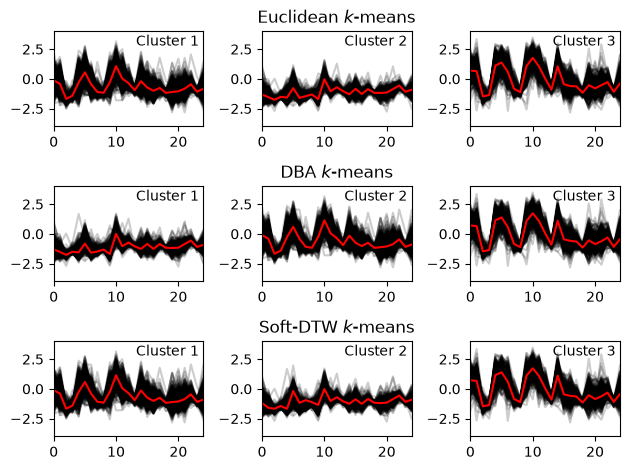

In [146]:
# Euclidean k-means
print("Euclidean k-means")
km = TimeSeriesKMeans(n_clusters=3, verbose=True, random_state=seed)
y_pred = km.fit_predict(X_train)

plt.figure()
for yi in range(3):
    plt.subplot(3, 3, yi + 1)
    for xx in X_train[y_pred == yi]:
        plt.plot(xx.ravel(), "k-", alpha=.2)
    plt.plot(km.cluster_centers_[yi].ravel(), "r-")
    plt.xlim(0, sz)
    plt.ylim(-4, 4)
    plt.text(0.55, 0.85,'Cluster %d' % (yi + 1),
             transform=plt.gca().transAxes)
    if yi == 1:
        plt.title("Euclidean $k$-means")

# DBA-k-means
print("DBA k-means")
dba_km = TimeSeriesKMeans(n_clusters=3,
                          n_init=2,
                          metric="dtw",
                          verbose=True,
                          max_iter_barycenter=10,
                          random_state=seed)
y_pred = dba_km.fit_predict(X_train)

for yi in range(3):
    plt.subplot(3, 3, 4 + yi)
    for xx in X_train[y_pred == yi]:
        plt.plot(xx.ravel(), "k-", alpha=.2)
    plt.plot(dba_km.cluster_centers_[yi].ravel(), "r-")
    plt.xlim(0, sz)
    plt.ylim(-4, 4)
    plt.text(0.55, 0.85,'Cluster %d' % (yi + 1),
             transform=plt.gca().transAxes)
    if yi == 1:
        plt.title("DBA $k$-means")

# Soft-DTW-k-means
print("Soft-DTW k-means")
sdtw_km = TimeSeriesKMeans(n_clusters=3,
                           metric="softdtw",
                           metric_params={"gamma": .01},
                           verbose=True,
                           random_state=seed)
y_pred = sdtw_km.fit_predict(X_train)

for yi in range(3):
    plt.subplot(3, 3, 7 + yi)
    for xx in X_train[y_pred == yi]:
        plt.plot(xx.ravel(), "k-", alpha=.2)
    plt.plot(sdtw_km.cluster_centers_[yi].ravel(), "r-")
    plt.xlim(0, sz)
    plt.ylim(-4, 4)
    plt.text(0.55, 0.85,'Cluster %d' % (yi + 1),
             transform=plt.gca().transAxes)
    if yi == 1:
        plt.title("Soft-DTW $k$-means")

plt.tight_layout()
plt.show()

Euclidean k-means
41.663 --> 26.929 --> 26.108 --> 25.949 --> 25.893 --> 25.868 --> 25.860 --> 25.857 --> 25.855 --> 25.854 --> 25.853 --> 25.853 --> 
DBA k-means
Init 1
38.832 --> 26.514 --> 25.994 --> 25.738 --> 25.572 --> 25.442 --> 25.356 --> 25.291 --> 25.253 --> 25.241 --> 25.233 --> 25.226 --> 25.221 --> 25.217 --> 25.214 --> 25.213 --> 25.212 --> 25.210 --> 25.208 --> 25.205 --> 25.202 --> 25.197 --> 25.195 --> 25.193 --> 25.190 --> 25.187 --> 25.185 --> 25.183 --> 25.183 --> 25.183 --> 
Init 2
42.218 --> 27.964 --> 26.807 --> 26.326 --> 26.104 --> 25.973 --> 25.882 --> 25.812 --> 25.746 --> 25.674 --> 25.613 --> 25.551 --> 25.491 --> 25.434 --> 25.392 --> 25.363 --> 25.332 --> 25.316 --> 25.303 --> 25.298 --> 25.290 --> 25.280 --> 25.270 --> 25.262 --> 25.255 --> 25.250 --> 25.247 --> 25.244 --> 25.241 --> 25.238 --> 25.234 --> 25.232 --> 25.230 --> 25.229 --> 25.228 --> 25.227 --> 25.226 --> 25.225 --> 25.224 --> 25.223 --> 25.222 --> 25.221 --> 25.220 --> 25.219 --> 25.219 -

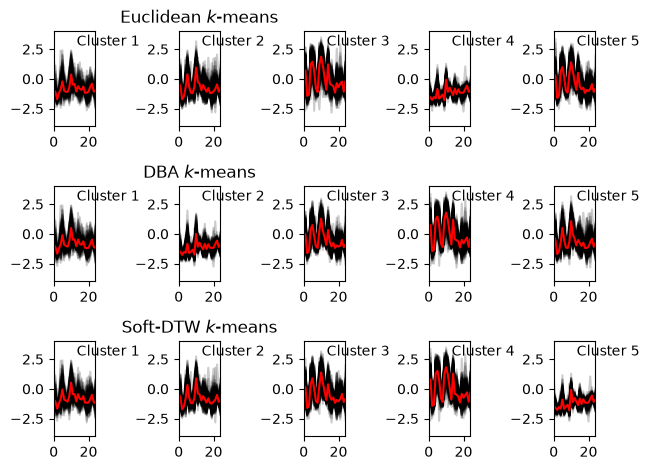

In [149]:
N_CLUSTERS = 5

# Euclidean k-means
print("Euclidean k-means")
km = TimeSeriesKMeans(n_clusters=N_CLUSTERS, verbose=True, random_state=seed)
y_pred = km.fit_predict(X_train)

plt.figure()
for yi in range(N_CLUSTERS):
    plt.subplot(3, N_CLUSTERS, yi + 1)
    for xx in X_train[y_pred == yi]:
        plt.plot(xx.ravel(), "k-", alpha=.2)
    plt.plot(km.cluster_centers_[yi].ravel(), "r-")
    plt.xlim(0, sz)
    plt.ylim(-4, 4)
    plt.text(0.55, 0.85,'Cluster %d' % (yi + 1),
             transform=plt.gca().transAxes)
    if yi == 1:
        plt.title("Euclidean $k$-means")

# DBA-k-means
print("DBA k-means")
dba_km = TimeSeriesKMeans(n_clusters=N_CLUSTERS,
                          n_init=2,
                          metric="dtw",
                          verbose=True,
                          max_iter_barycenter=10,
                          random_state=seed)
y_pred = dba_km.fit_predict(X_train)

for yi in range(N_CLUSTERS):
    plt.subplot(3, N_CLUSTERS, N_CLUSTERS * 1 + 1 + yi)
    for xx in X_train[y_pred == yi]:
        plt.plot(xx.ravel(), "k-", alpha=.2)
    plt.plot(dba_km.cluster_centers_[yi].ravel(), "r-")
    plt.xlim(0, sz)
    plt.ylim(-4, 4)
    plt.text(0.55, 0.85,'Cluster %d' % (yi + 1),
             transform=plt.gca().transAxes)
    if yi == 1:
        plt.title("DBA $k$-means")

# Soft-DTW-k-means
print("Soft-DTW k-means")
sdtw_km = TimeSeriesKMeans(n_clusters=N_CLUSTERS,
                           metric="softdtw",
                           metric_params={"gamma": .01},
                           verbose=True,
                           random_state=seed)
y_pred = sdtw_km.fit_predict(X_train)

for yi in range(N_CLUSTERS):
    plt.subplot(3, N_CLUSTERS, N_CLUSTERS * 2 + 1 + yi)
    for xx in X_train[y_pred == yi]:
        plt.plot(xx.ravel(), "k-", alpha=.2)
    plt.plot(sdtw_km.cluster_centers_[yi].ravel(), "r-")
    plt.xlim(0, sz)
    plt.ylim(-4, 4)
    plt.text(0.55, 0.85,'Cluster %d' % (yi + 1),
             transform=plt.gca().transAxes)
    if yi == 1:
        plt.title("Soft-DTW $k$-means")

plt.tight_layout()
plt.show()